In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/hab_labels_final.csv", low_memory=False)
df['time'] = pd.to_datetime(df['time'], utc=True)
df['date'] = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (1358852, 42)
Columns: ['cruise_name', 'station_name', 'time', 'latitude_x', 'longitude_x', 'depth_code', 'depth', 'sea_water_pressure', 'sea_water_electrical_conductivity', 'sea_water_temperature', 'oxygen_sensor_temp', 'PAR', 'Chlorophyll', 'Corrected_Chlorophyll', 'pH', 'sea_water_salinity', 'oxygen_concentration_in_sea_water', 'winkler', 'corrected_oxygen', 'percent_saturation_100', 'percent_saturation', 'sea_water_density', 'Start_Date', 'End_Date', 'Time_ON_Station', 'Time_OFF_Station', 'bloom', 'year', 'month', 'season', 'date', 'Station_Name', 'latitude_y', 'longitude_y', 'CHLA', 'DIP', 'NH#-LC', 'NOX-LC', 'TDN-LC', 'chl_climatology', 'chl_anomaly', 'chl_anomaly_pct']


In [2]:
# Keep only useful columns
keep = [
    'station_name', 'time', 'date', 'latitude_x', 'longitude_x',
    'depth_code', 'sea_water_temperature', 'sea_water_salinity',
    'oxygen_concentration_in_sea_water', 'Chlorophyll', 'Corrected_Chlorophyll',
    'pH', 'sea_water_density', 'PAR',
    'DIP', 'NH#-LC', 'NOX-LC', 'TDN-LC',
    'chl_climatology', 'chl_anomaly', 'chl_anomaly_pct',
    'year', 'month', 'season', 'bloom'
]

df = df[keep].rename(columns={
    'latitude_x': 'latitude',
    'longitude_x': 'longitude'
})

print(f"Clean shape: {df.shape}")
print(df.dtypes)

Clean shape: (1358852, 25)
station_name                                         str
time                                 datetime64[us, UTC]
date                                      datetime64[us]
latitude                                         float64
longitude                                        float64
depth_code                                           str
sea_water_temperature                            float64
sea_water_salinity                               float64
oxygen_concentration_in_sea_water                float64
Chlorophyll                                      float64
Corrected_Chlorophyll                            float64
pH                                               float64
sea_water_density                                float64
PAR                                              float64
DIP                                              float64
NH#-LC                                           float64
NOX-LC                                           float64
TDN-

In [3]:
# Sort by station and time
df = df.sort_values(['station_name', 'date']).reset_index(drop=True)

# Build lagged features per station
print("Computing lagged features...")

for lag in [3, 7, 14, 21]:
    df[f'chl_lag{lag}'] = df.groupby('station_name')['Chlorophyll'].shift(lag)
    df[f'temp_lag{lag}'] = df.groupby('station_name')['sea_water_temperature'].shift(lag)

# 7-day rolling mean and trend
df['chl_roll7_mean'] = df.groupby('station_name')['Chlorophyll'].transform(
    lambda x: x.rolling(7, min_periods=2).mean()
)
df['chl_roll7_std'] = df.groupby('station_name')['Chlorophyll'].transform(
    lambda x: x.rolling(7, min_periods=2).std()
)

print("Done.")
print(f"Shape: {df.shape}")

# Check correlations of lagged features with bloom
print("\nLagged feature correlations with bloom:")
for col in ['chl_lag3', 'chl_lag7', 'chl_lag14', 'chl_lag21', 'chl_roll7_mean']:
    corr = df[col].corr(df['bloom'])
    print(f"  {col}: {corr:.3f}")

Computing lagged features...
Done.
Shape: (1358852, 35)

Lagged feature correlations with bloom:
  chl_lag3: 0.661
  chl_lag7: 0.609
  chl_lag14: 0.528
  chl_lag21: 0.466
  chl_roll7_mean: 0.681


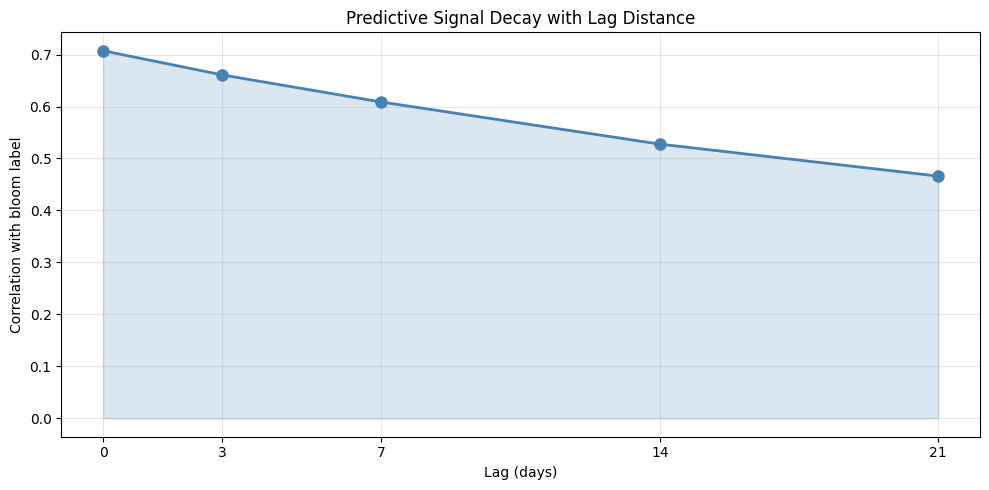

In [4]:
lags = [0, 3, 7, 14, 21]
corrs = [
    df['Chlorophyll'].corr(df['bloom']),
    df['chl_lag3'].corr(df['bloom']),
    df['chl_lag7'].corr(df['bloom']),
    df['chl_lag14'].corr(df['bloom']),
    df['chl_lag21'].corr(df['bloom']),
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lags, corrs, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.fill_between(lags, corrs, alpha=0.2, color='steelblue')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Correlation with bloom label')
ax.set_title('Predictive Signal Decay with Lag Distance')
ax.grid(True, alpha=0.3)
ax.set_xticks(lags)
plt.tight_layout()
plt.savefig('../figures/lag_correlation_decay.png', dpi=150)
plt.show()

In [5]:
df.to_csv("../data/hab_features_final.csv", index=False)
print(f"Saved. Shape: {df.shape}")

Saved. Shape: (1358852, 35)
